<a href="https://colab.research.google.com/github/adimika04-collab/Jaringan-Saraf-Tiruan/blob/main/Proyek_UTS_JST_Mika.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

5 Data Teratas:
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0     6        

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(



===== HASIL LOGISTIC REGRESSION =====
Accuracy: 0.8
Confusion Matrix:
 [[34  1]
 [11 14]]
              precision    recall  f1-score   support

           0       0.76      0.97      0.85        35
           1       0.93      0.56      0.70        25

    accuracy                           0.80        60
   macro avg       0.84      0.77      0.77        60
weighted avg       0.83      0.80      0.79        60

ROC-AUC: 0.7657142857142858

===== HASIL NEURAL NETWORK (MLP) =====
Accuracy: 0.6666666666666666
Confusion Matrix:
 [[28  7]
 [13 12]]
              precision    recall  f1-score   support

           0       0.68      0.80      0.74        35
           1       0.63      0.48      0.55        25

    accuracy                           0.67        60
   macro avg       0.66      0.64      0.64        60
weighted avg       0.66      0.67      0.66        60

ROC-AUC: 0.64


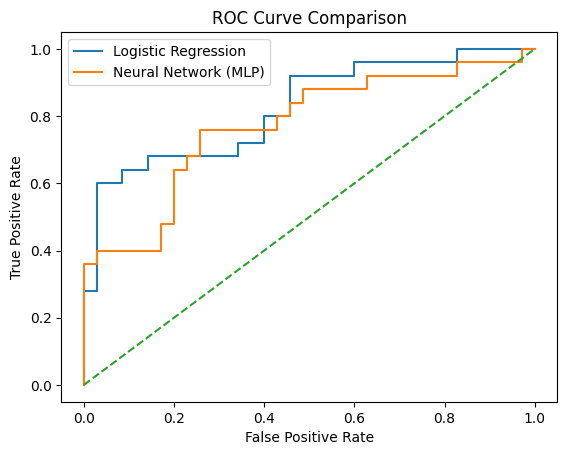

In [1]:
# ================================
# 1. IMPORT LIBRARY
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# ================================
# 2. LOAD DATA
# ================================
data = pd.read_csv("/content/heart_failure_clinical_records_dataset.csv")

print("5 Data Teratas:")
print(data.head())

print("\nInfo Dataset:")
print(data.info())

# ================================
# 3. DEFINISI FITUR & TARGET
# ================================
X = data.drop("DEATH_EVENT", axis=1)   # fitur
y = data["DEATH_EVENT"]                # target (0 = hidup, 1 = meninggal)

# ================================
# 4. SPLIT DATA
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# 5. SCALING DATA
# ================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ================================
# 6. MODEL 1 - LOGISTIC REGRESSION
# ================================
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

# ================================
# 7. MODEL 2 - NEURAL NETWORK (MLP)
# ================================
mlp_model = MLPClassifier(
    hidden_layer_sizes=(16,8),
    activation='relu',
    max_iter=1000,
    random_state=42
)

mlp_model.fit(X_train, y_train)

y_pred_mlp = mlp_model.predict(X_test)

# ================================
# 8. EVALUASI MODEL
# ================================
print("\n===== HASIL LOGISTIC REGRESSION =====")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_log))

print("\n===== HASIL NEURAL NETWORK (MLP) =====")
print("Accuracy:", accuracy_score(y_test, y_pred_mlp))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_mlp))

# ================================
# 9. VISUALISASI ROC CURVE
# ================================
y_prob_log = log_model.predict_proba(X_test)[:,1]
y_prob_mlp = mlp_model.predict_proba(X_test)[:,1]

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_prob_mlp)

plt.figure()
plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_mlp, tpr_mlp, label="Neural Network (MLP)")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()